# 2024-09-11 We

### A 10-mm femur-length difference is roughly an inch in height...

* For males: Height = 2.32 × Femur Length + 655.3
* For females: Height = 2.47 × Femur Length + 541.0
* For males: a 400 mm femur = 5'2.3"
* For females: a 400 mm femur = 5'0.2"
* For males: a 450 mm femur = 5'6.9"
* For females: a 450 mm femur = 5'5.1"
* For males: a 500 mm femur = 5'11.5"
* For females: a 500 mm femer = 5'9.9"


### The Roman Empire Around the Year 200

![The Roman Empire Around the Year 200 Map](2024-09-13-econ-135/roman_empire_200.png)

### The Province Britanna

![The Province Britanna Map](2024-09-13-econ-135/britannia.png)

### The Northwest European Provinces

![The Northwest European Provinces Map](2024-09-13-econ-135/northwesteurope.png)

In [1]:
provinces = [
    "Achaea", "Aegyptus", "Africa", "Alpes Cottiae", "Alpes Maritimae", "Alpes Poeninae",
    "Arabia Petrae", "Armenia", "Asia", "Assyria", "Bithynia et Pontus", "Britannia",
    "Cappadocia", "Cilicia", "Corsica et Sardinia", "Creta et Cyrenaica", "Cyprus", "Dacia",
    "Dalmatia", "Epirus", "Galatia", "Gallia Aquitania", "Gallia Belgica", "Gallia Lugdunensis",
    "Gallia Narbonensis", "Germania Inferior", "Germania Superior", "Hispania Baetica",
    "Hispania Tarraconensis", "Italia", "Iudaea", "Lusitania", "Lycia et Pamphylia", "Macedonia",
    "Mauretania Caesariensis", "Mauretania Tingitana", "Mesopotamia", "Moesia Inferior",
    "Moesia Superior", "Noricum", "Pannonia Inferior", "Pannonia Superior", "Raetia", "Sicilia",
    "Syria", "Taurica", "Thracia"
]

numbered_provinces = {i+1: province for i, province in enumerate(provinces)}


import pandas as pd

# Create a DataFrame from the numbered provinces
numbered_provinces_df = pd.DataFrame(list(numbered_provinces.items()), columns=["Number", "Province"])

numbered_provinces_df

,Number,Province
0,1,Achaea
1,2,Aegyptus
2,3,Africa
3,4,Alpes Cottiae
4,5,Alpes Maritimae
5,6,Alpes Poeninae
6,7,Arabia Petrae
7,8,Armenia
8,9,Asia
9,10,Assyria


In [2]:
import pandas as pd

df = pd.read_csv('2024-09-13-econ-135/roman_femurs.csv')

df.head()

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy
0,400.92,30,0,1,0,0,0,800,1
1,401.17,30,0,1,0,0,0,800,1
2,400.68,30,0,1,0,0,0,800,1
3,400.38,30,0,1,0,0,0,800,1
4,400.48,30,0,1,0,0,0,800,1


In [3]:
len(df)

38031

In [4]:
type(numbered_provinces)

dict

In [5]:
df['ProvinceName'] = df['Province'].map(numbered_provinces)

In [6]:
df.head()

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy,ProvinceName
0,400.92,30,0,1,0,0,0,800,1,Italia
1,401.17,30,0,1,0,0,0,800,1,Italia
2,400.68,30,0,1,0,0,0,800,1,Italia
3,400.38,30,0,1,0,0,0,800,1,Italia
4,400.48,30,0,1,0,0,0,800,1,Italia


In [7]:
df_britannia = df[df['ProvinceName'] == 'Britannia']

In [8]:
df_britannia

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy,ProvinceName
11254,434.36,12,0,0,0,0,1,467,0,Britannia
11255,434.60,12,0,0,0,0,1,467,0,Britannia
11256,435.19,12,0,0,0,0,1,467,0,Britannia
11257,435.39,12,0,0,0,0,1,467,0,Britannia
11258,436.02,12,0,0,0,0,1,467,0,Britannia
...,...,...,...,...,...,...,...,...,...,...
37919,424.00,12,1,0,0,0,1,450,0,Britannia
37920,424.00,12,1,0,0,0,1,450,0,Britannia
37921,424.00,12,1,0,0,0,1,450,0,Britannia
37922,424.00,12,1,0,0,0,1,450,0,Britannia


In [9]:
df_britannia = df_britannia.drop(columns=['ProvinceName'])

In [10]:
df_britannia.head()

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy
11254,434.36,12,0,0,0,0,1,467,0
11255,434.60,12,0,0,0,0,1,467,0
11256,435.19,12,0,0,0,0,1,467,0
11257,435.39,12,0,0,0,0,1,467,0
11258,436.02,12,0,0,0,0,1,467,0


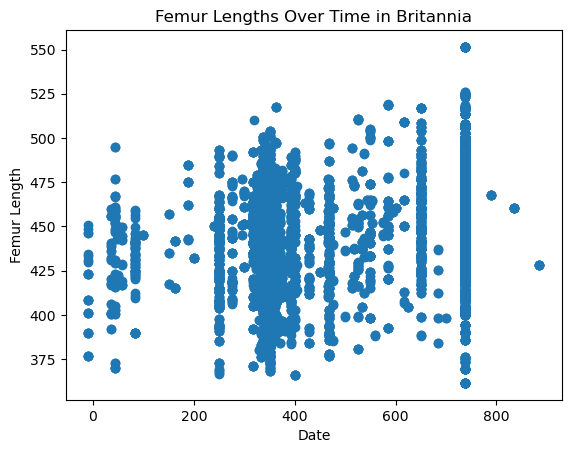

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df_britannia['Date'], df_britannia['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths Over Time in Britannia')

# Display the plot
plt.show()

/tmp/ipykernel_106/1277810657.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_britannia.groupby('Date_bin')['Femur'].mean().reset_index()


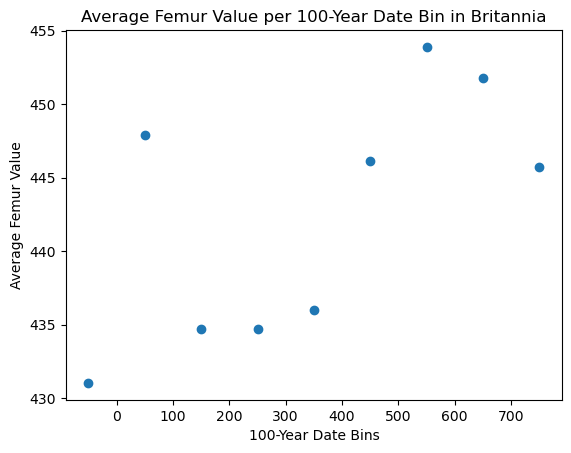

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_britannia['Date'].min(), df_britannia['Date'].max() + 100, 100)
df_britannia['Date_bin'] = pd.cut(df_britannia['Date'], bins)

grouped_data = df_britannia.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-50+100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-Year Date Bins')
plt.ylabel('Average Femur Value')
plt.title('Average Femur Value per 100-Year Date Bin in Britannia')
plt.show()

In [13]:
df_WesternMediterranean = df[df['WesternMediterranean'] == 1]
df_GreekEast = df[df['GreekEast'] == 1]
df_NorthWestEurope = df[df['NorthWestEurope'] == 1]
df_SouthEastEurope = df[df['SouthEastEurope'] == 1]

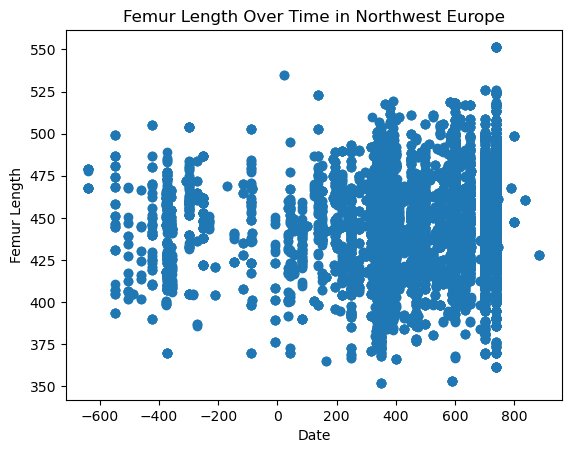

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df_NorthWestEurope['Date'], df_NorthWestEurope['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in Northwest Europe')

# Display the plot
plt.show()

/tmp/ipykernel_476/2793703575.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NorthWestEurope['Date_bin'] = pd.cut(df_NorthWestEurope['Date'], bins)
/tmp/ipykernel_476/2793703575.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_NorthWestEurope.groupby('Date_bin')['Femur'].mean().reset_index()


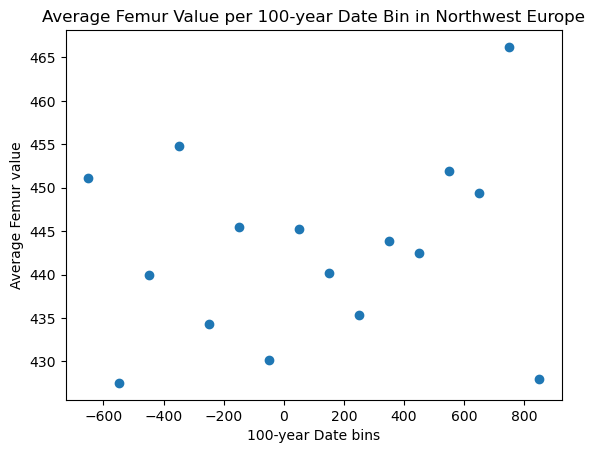

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_NorthWestEurope['Date'].min(), df_NorthWestEurope['Date'].max() + 100, 100)
df_NorthWestEurope['Date_bin'] = pd.cut(df_NorthWestEurope['Date'], bins)

grouped_data = df_NorthWestEurope.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-year Date bins')
plt.ylabel('Average Femur value')
plt.title('Average Femur Value per 100-year Date Bin in Northwest Europe')
plt.show()

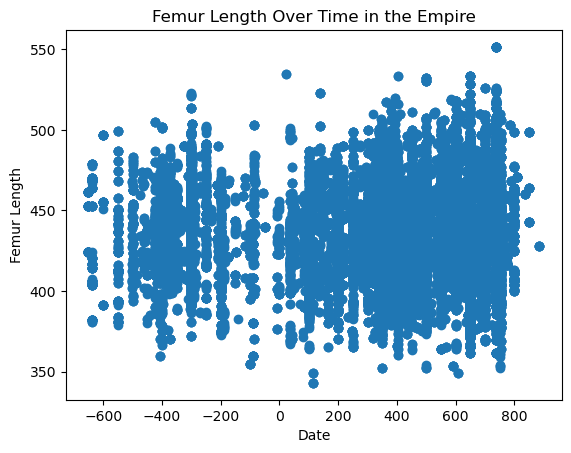

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df['Date'], df['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in the Empire')

# Display the plot
plt.show()

/tmp/ipykernel_476/3765878134.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby('Date_bin')['Femur'].mean().reset_index()


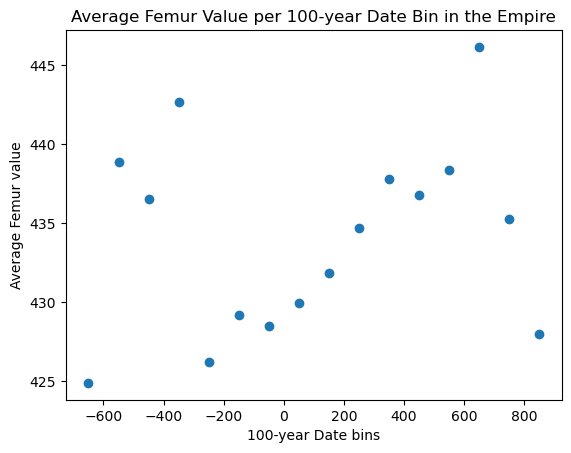

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df['Date'].min(), df['Date'].max() + 100, 100)
df['Date_bin'] = pd.cut(df['Date'], bins)

grouped_data = df.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-year Date bins')
plt.ylabel('Average Femur value')
plt.title('Average Femur Value per 100-year Date Bin in the Empire')
plt.show()

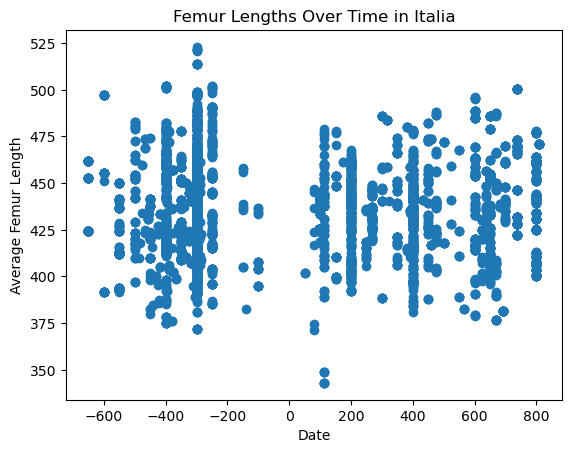

In [18]:
df_italia = df[df['ProvinceName'] == 'Italia']

import matplotlib.pyplot as plt

plt.scatter(df_italia['Date'], df_italia['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Femur Lengths Over Time in Italia')

# Display the plot
plt.show()

/tmp/ipykernel_476/3752075431.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_italia['Date_bin'] = pd.cut(df_italia['Date'], bins)
/tmp/ipykernel_476/3752075431.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_italia.groupby('Date_bin')['Femur'].mean().reset_index()


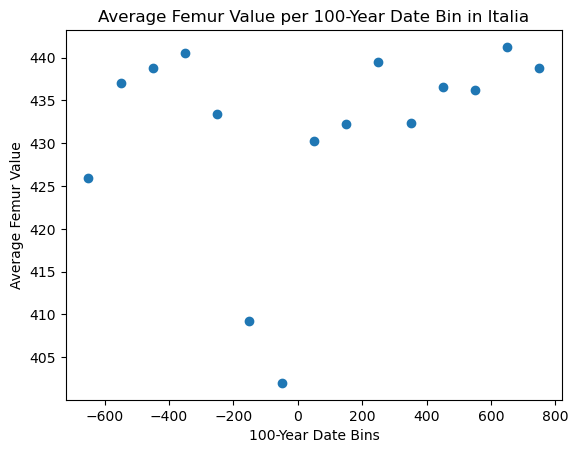

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_italia['Date'].min(), df_italia['Date'].max() + 100, 100)
df_italia['Date_bin'] = pd.cut(df_italia['Date'], bins)

grouped_data = df_italia.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-Year Date Bins')
plt.ylabel('Average Femur Value')
plt.title('Average Femur Value per 100-Year Date Bin in Italia')
plt.show()

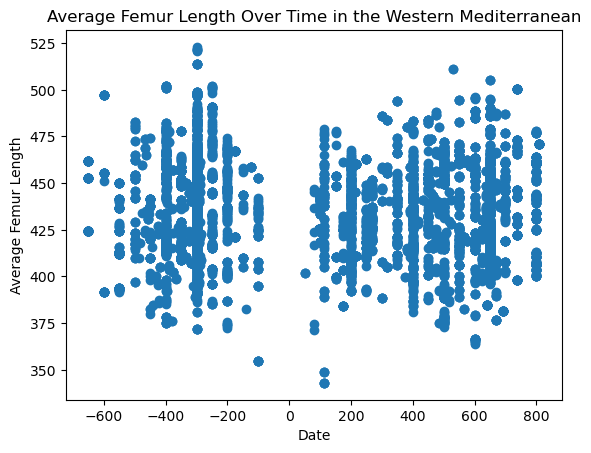

In [20]:
import matplotlib.pyplot as plt

plt.scatter(df_WesternMediterranean['Date'], df_WesternMediterranean['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Average Femur Length Over Time in the Western Mediterranean')

# Display the plot
plt.show()

/tmp/ipykernel_476/2405607497.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WesternMediterranean['Date_bin'] = pd.cut(df_WesternMediterranean['Date'], bins)
/tmp/ipykernel_476/2405607497.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_WesternMediterranean.groupby('Date_bin')['Femur'].mean().reset_index()


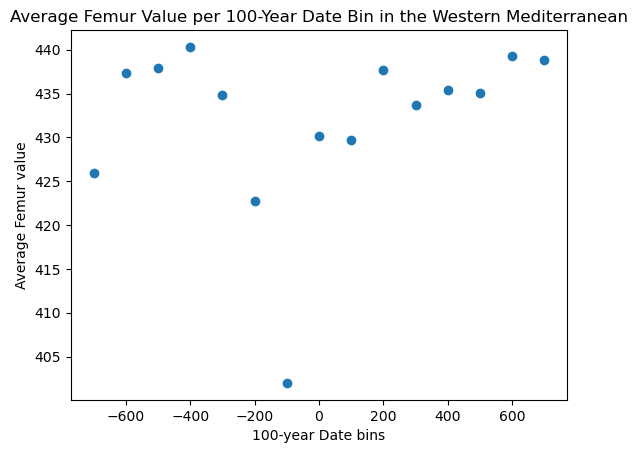

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_WesternMediterranean['Date'].min(), df_WesternMediterranean['Date'].max() + 100, 100)
df_WesternMediterranean['Date_bin'] = pd.cut(df_WesternMediterranean['Date'], bins)

grouped_data = df_WesternMediterranean.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-700 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-year Date bins')
plt.ylabel('Average Femur value')
plt.title('Average Femur Value per 100-Year Date Bin in the Western Mediterranean')
plt.show()

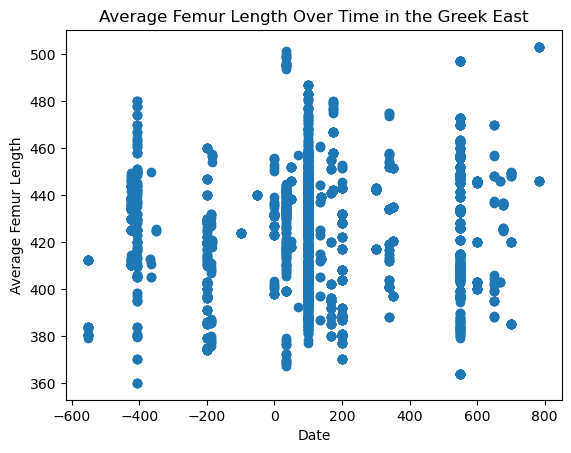

In [22]:
import matplotlib.pyplot as plt

plt.scatter(df_GreekEast['Date'], df_GreekEast['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Average Femur Length Over Time in the Greek East')

# Display the plot
plt.show()

/tmp/ipykernel_476/3637229735.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GreekEast['Date_bin'] = pd.cut(df_GreekEast['Date'], bins)
/tmp/ipykernel_476/3637229735.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_GreekEast.groupby('Date_bin')['Femur'].mean().reset_index()


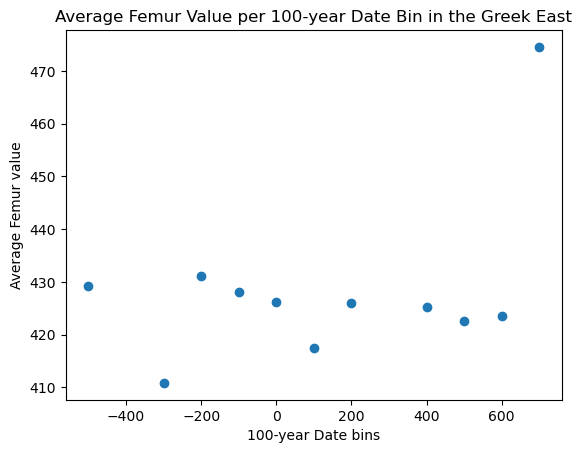

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_GreekEast['Date'].min(), df_GreekEast['Date'].max() + 100, 100)
df_GreekEast['Date_bin'] = pd.cut(df_GreekEast['Date'], bins)

grouped_data = df_GreekEast.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-600 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-year Date bins')
plt.ylabel('Average Femur value')
plt.title('Average Femur Value per 100-year Date Bin in the Greek East')
plt.show()

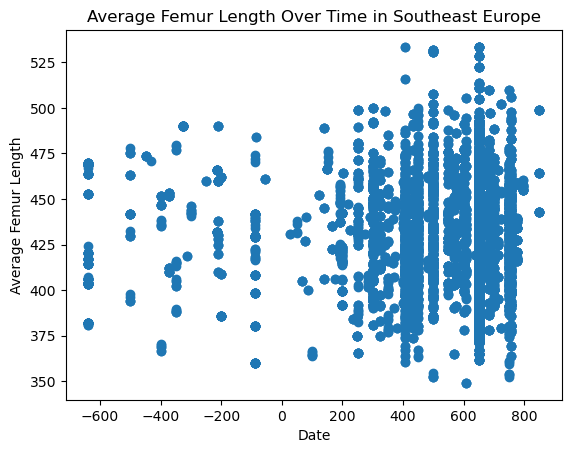

In [24]:
import matplotlib.pyplot as plt

plt.scatter(df_SouthEastEurope['Date'], df_SouthEastEurope['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Average Femur Length Over Time in Southeast Europe')

# Display the plot
plt.show()

/tmp/ipykernel_476/813404395.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SouthEastEurope['Date_bin'] = pd.cut(df_SouthEastEurope['Date'], bins)
/tmp/ipykernel_476/813404395.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_SouthEastEurope.groupby('Date_bin')['Femur'].mean().reset_index()


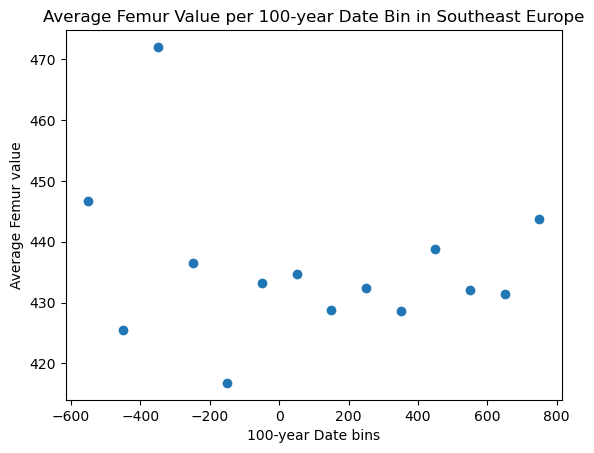

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_SouthEastEurope['Date'].min(), df_SouthEastEurope['Date'].max() + 100, 100)
df_SouthEastEurope['Date_bin'] = pd.cut(df_SouthEastEurope['Date'], bins)

grouped_data = df_SouthEastEurope.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('100-year Date bins')
plt.ylabel('Average Femur value')
plt.title('Average Femur Value per 100-year Date Bin in Southeast Europe')
plt.show()